Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully!


Saving juice.jpeg to juice.jpeg
Saving globe.jpeg to globe (1).jpeg
Saving auto.jpeg to auto (2).jpeg
Saving woodpecker.jpeg to woodpecker (5).jpeg
Saving strawberry.jpeg to strawberry (5).jpeg
Saving rose.jpg to rose (5).jpg
Saving cheetah.jpeg to cheetah (5).jpeg
Saving train.jpeg to train (6).jpeg
Saving orng.jpeg to orng (6).jpeg
Saving person.jpg to person (7).jpg
Saving parrot.jpeg to parrot (7).jpeg
Saving banana.jpeg to banana (7).jpeg
Saving dog.jpeg to dog (7).jpeg
Saving cat.jpg to cat (7).jpg
Saving starfruit.jpeg to starfruit (7).jpeg
Saving apple.jpg to apple (7).jpg
📂 Total images uploaded: 16


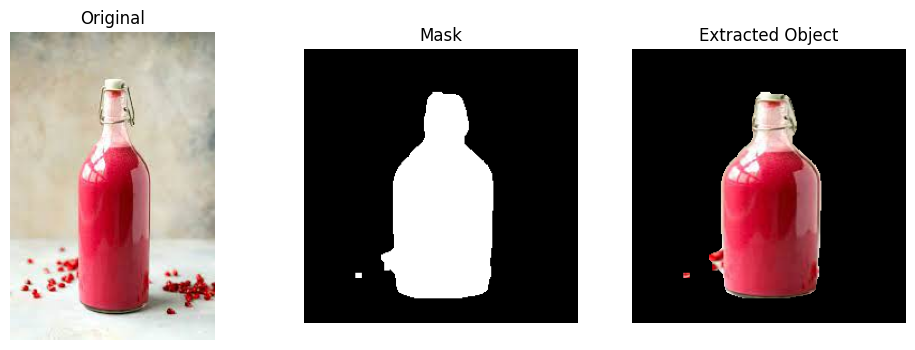

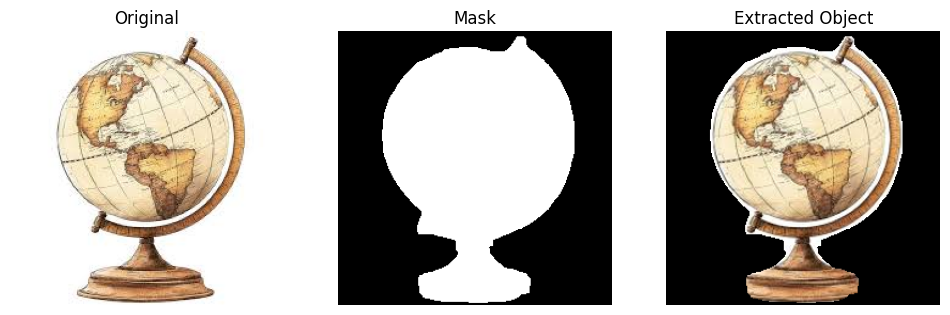

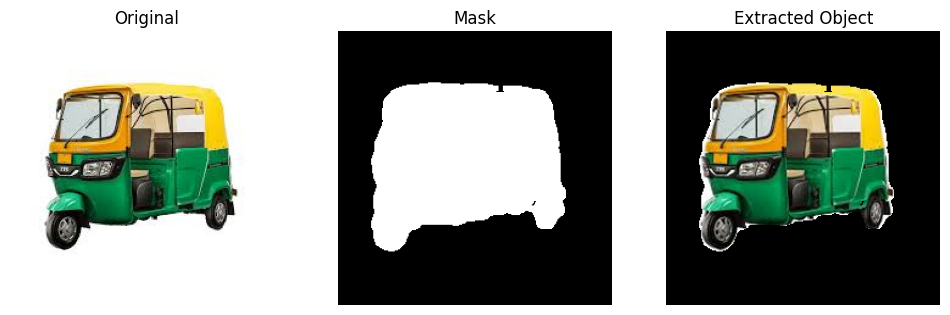

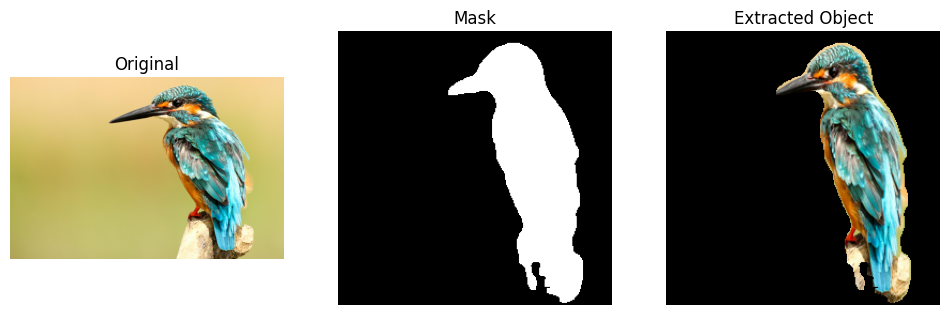

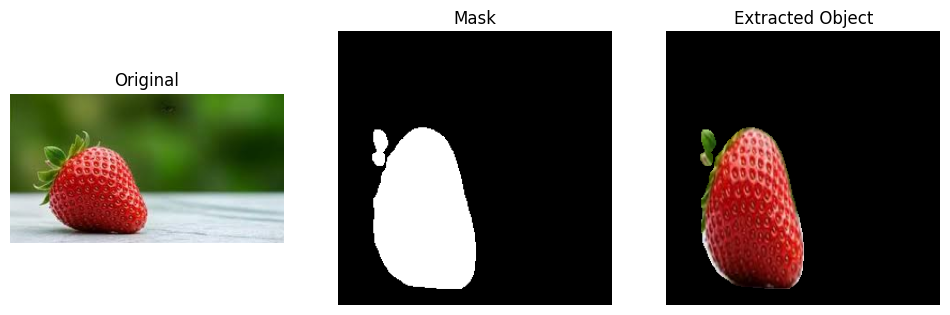

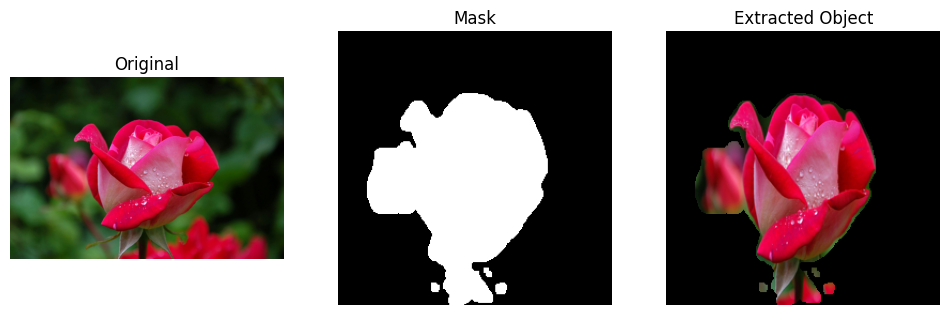

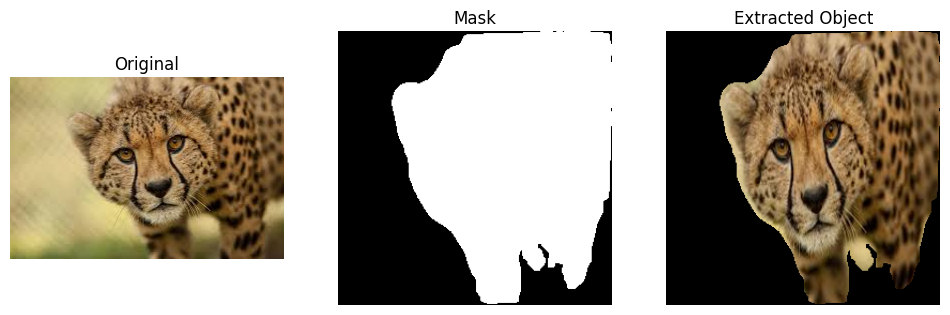

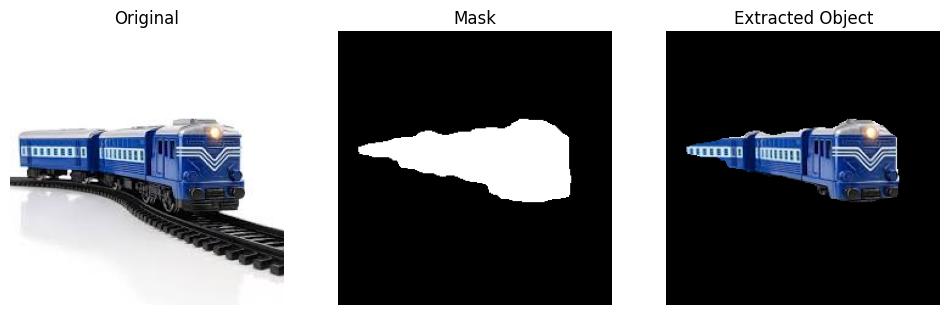

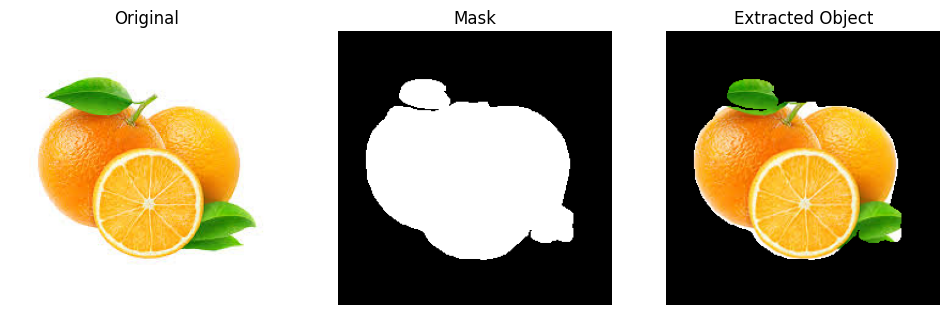

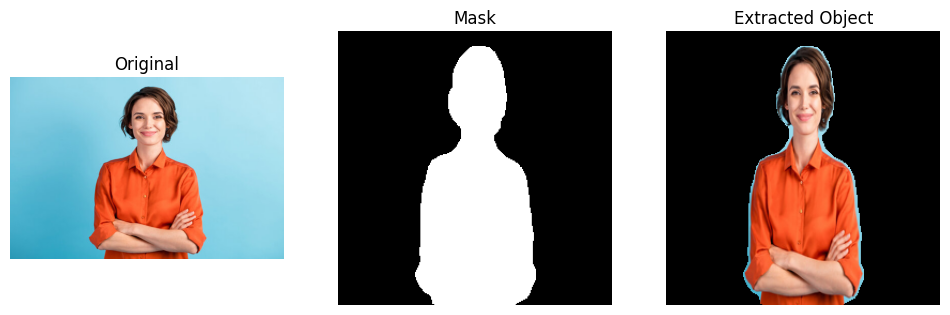

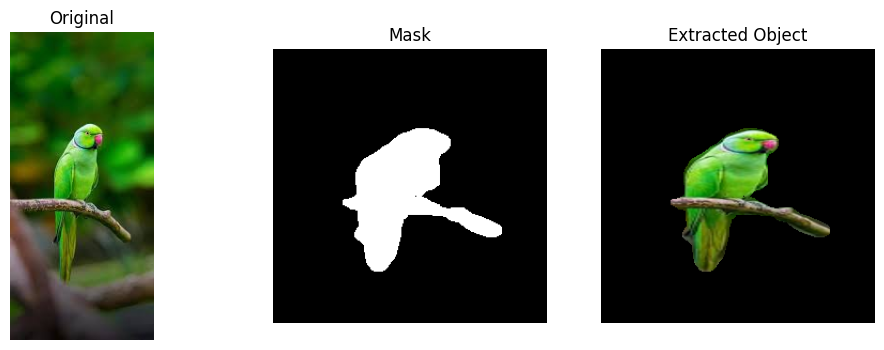

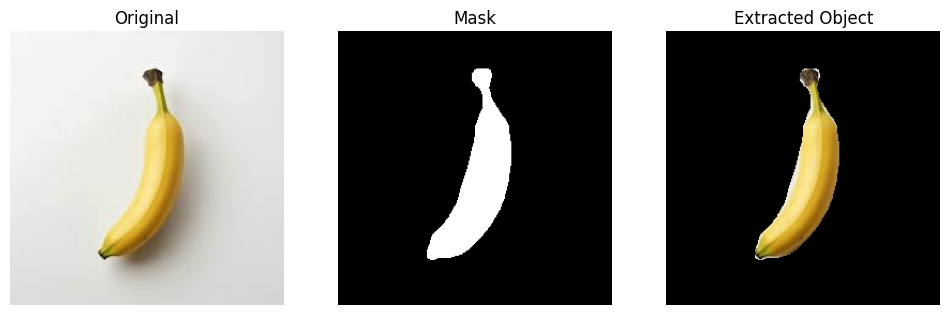

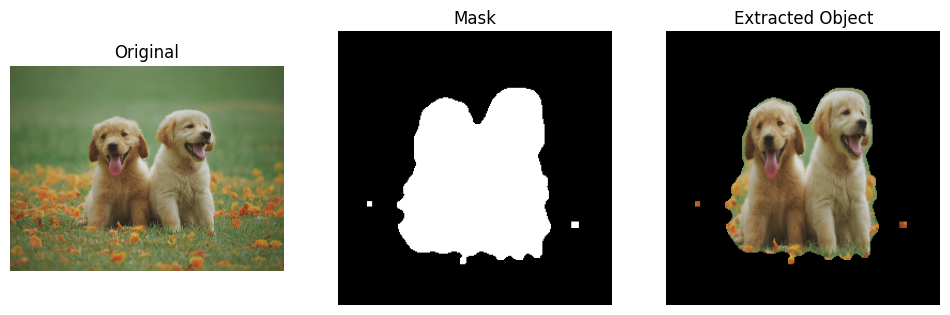

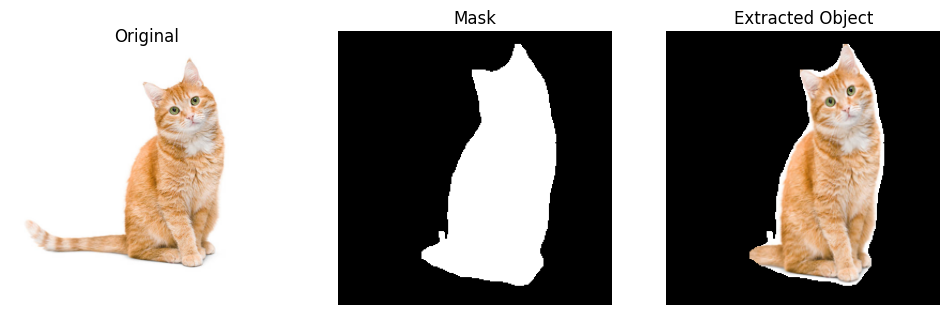

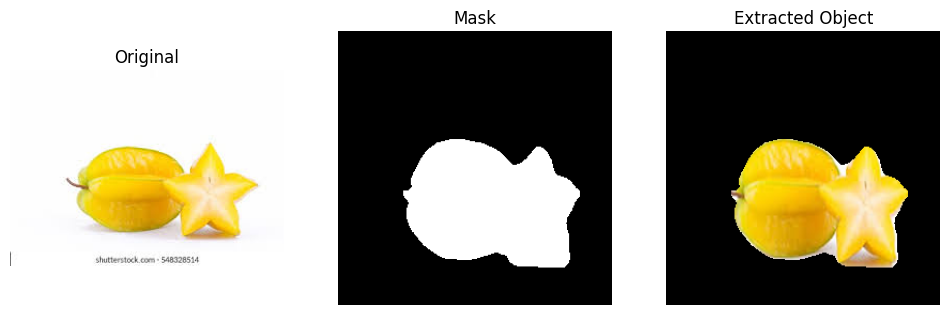

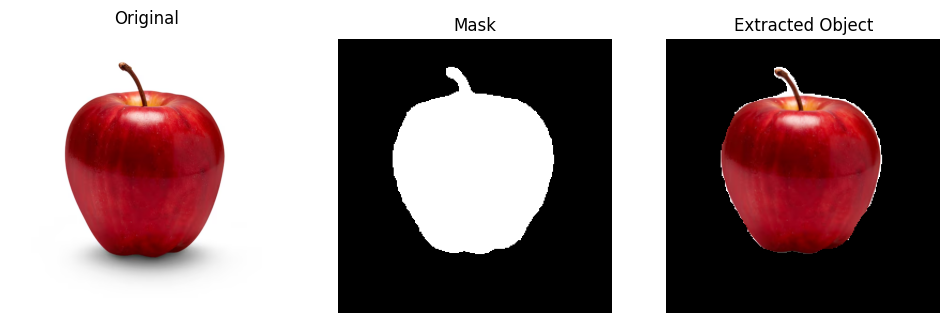

✅ Inference completed. Results & masks saved in 'outputs' folder.


In [8]:
# ===========================
# 1. Install required libraries
# ===========================
!pip install segmentation-models-pytorch --quiet
!pip install torch torchvision pillow numpy matplotlib opencv-python --quiet

# ===========================
# 2. Import libraries
# ===========================
import torch
import segmentation_models_pytorch as smp
from PIL import Image
import torchvision.transforms as T
import numpy as np
from google.colab import files, drive
import os
import matplotlib.pyplot as plt
import cv2

# ===========================
# 3. Mount Google Drive
# ===========================
drive.mount('/content/drive')

# ===========================
# 4. Load the DeepLabV3+ model
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = '/content/drive/MyDrive/infosys_ai_vision_extract/best_deeplab.pth'

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found at {model_path}. Please check the path.")

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("✅ Model loaded successfully!")

# ===========================
# 5. Preprocessing
# ===========================
def preprocess_image(image):
    transform = T.Compose([
        T.Resize((256, 256)),  # match training size
        T.ToTensor(),
    ])
    return transform(image).unsqueeze(0)

# ===========================
# 6. Improved TTA Inference
# ===========================
def predict_with_tta(model, input_tensor):
    aug_list = [
        lambda x: x,  # original
        lambda x: torch.flip(x, [3]),  # horizontal flip
        lambda x: torch.flip(x, [2]),  # vertical flip
        lambda x: torch.rot90(x, k=1, dims=[2, 3]),  # rotate 90°
        lambda x: torch.rot90(x, k=3, dims=[2, 3])   # rotate 270°
    ]
    outputs = []
    for f in aug_list:
        t = f(input_tensor)
        with torch.no_grad():
            out = model(t)
            out = torch.sigmoid(out)
            # undo transforms
            if f != aug_list[0]:
                if f == aug_list[1]: out = torch.flip(out, [3])
                elif f == aug_list[2]: out = torch.flip(out, [2])
                elif f == aug_list[3]: out = torch.rot90(out, k=3, dims=[2, 3])
                elif f == aug_list[4]: out = torch.rot90(out, k=1, dims=[2, 3])
            outputs.append(out)
    return torch.mean(torch.stack(outputs), dim=0)

# ===========================
# 7. Smarter Post-processing
# ===========================
import cv2

def postprocess_mask(mask_tensor):
    mask = mask_tensor.squeeze().cpu().detach().numpy()

    # Adaptive threshold instead of fixed 0.5
    mask = (mask * 255).astype(np.uint8)
    _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological improvements
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)   # remove small noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # fill holes
    mask = cv2.dilate(mask, kernel, iterations=1)           # smooth edges

    return mask


# ===========================
# 8. Upload images manually
# ===========================
uploaded = files.upload()  # Opens file chooser in Colab
test_images = []
for file_name in uploaded.keys():
    img = Image.open(file_name).convert("RGB")
    test_images.append((file_name, img))

print(f"📂 Total images uploaded: {len(test_images)}")

# ===========================
# 9. Run inference, visualize, and save outputs
# ===========================
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/masks", exist_ok=True)  # Save masks separately

for img_name, img in test_images:
    input_tensor = preprocess_image(img).to(device)
    mask = predict_with_tta(model, input_tensor)
    mask_np = postprocess_mask(mask)

    # Save binary mask (black/white)
    mask_img = Image.fromarray(mask_np)
    mask_img.save(os.path.join("outputs/masks", f"mask_{os.path.basename(img_name)}"))

    # Overlay (extracted object)
    overlay = np.array(img.resize((256, 256))).copy()
    overlay[mask_np == 0] = [0, 0, 0]
    overlay_img = Image.fromarray(overlay)

    # Save overlay result
    overlay_img.save(os.path.join("outputs", os.path.basename(img_name)))

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Mask")
    plt.imshow(mask_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Extracted Object")
    plt.imshow(overlay_img)
    plt.axis("off")

    plt.show()

print("✅ Inference completed. Results & masks saved in 'outputs' folder.")
